In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

# Load data
conn = sqlite3.connect("../data/healthcare.db")
df = pd.read_sql("SELECT * FROM patients", conn)
conn.close()

print(f"✓ Data loaded: {df.shape[0]:,} rows · {df.shape[1]} columns")
print(f"✓ Readmission rate: {df['readmitted_30'].mean()*100:.1f}%")

✓ Data loaded: 71,518 rows · 28 columns
✓ Readmission rate: 8.8%


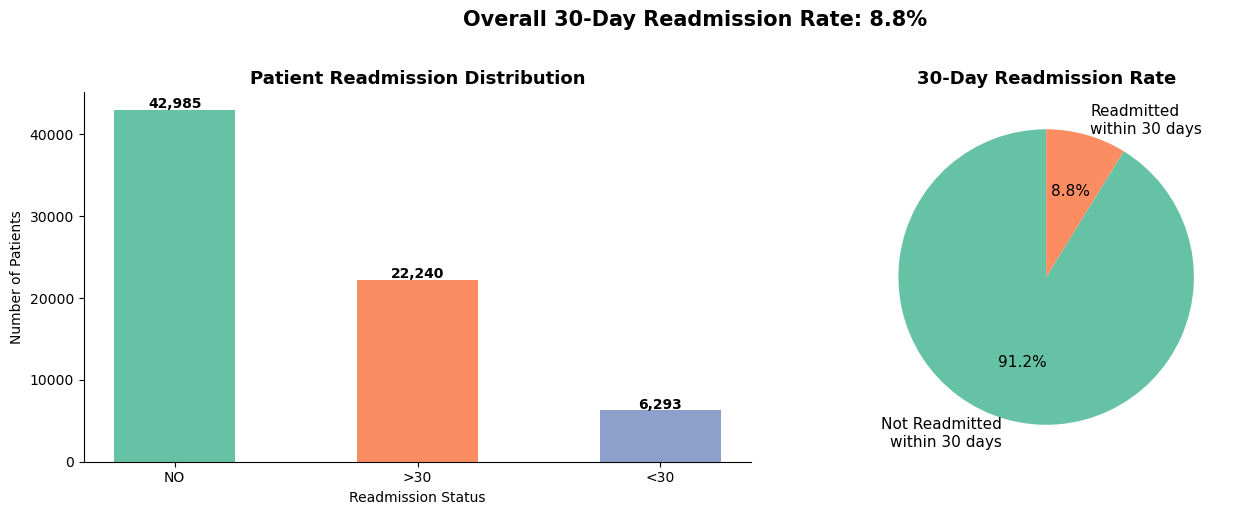

✓ Chart saved


In [2]:
# ── Overall readmission distribution ──────────────────────

readmit_counts = df["readmitted"].value_counts()
colors = ["#66c2a5", "#fc8d62", "#8da0cb"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — all three categories
axes[0].bar(readmit_counts.index, readmit_counts.values,
            color=colors, width=0.5)
axes[0].set_title("Patient Readmission Distribution",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xlabel("Readmission Status")
for i, val in enumerate(readmit_counts.values):
    axes[0].text(i, val + 200, f"{val:,}",
                 ha="center", fontweight="bold")

# Binary target distribution
binary_counts = df["readmitted_30"].value_counts()
binary_labels = ["Not Readmitted\nwithin 30 days",
                 "Readmitted\nwithin 30 days"]
axes[1].pie(binary_counts, labels=binary_labels,
            colors=["#66c2a5", "#fc8d62"],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("30-Day Readmission Rate",
                  fontsize=13, fontweight="bold")

plt.suptitle(
    f"Overall 30-Day Readmission Rate: "
    f"{df['readmitted_30'].mean()*100:.1f}%",
    fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../dashboard/01_readmission_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

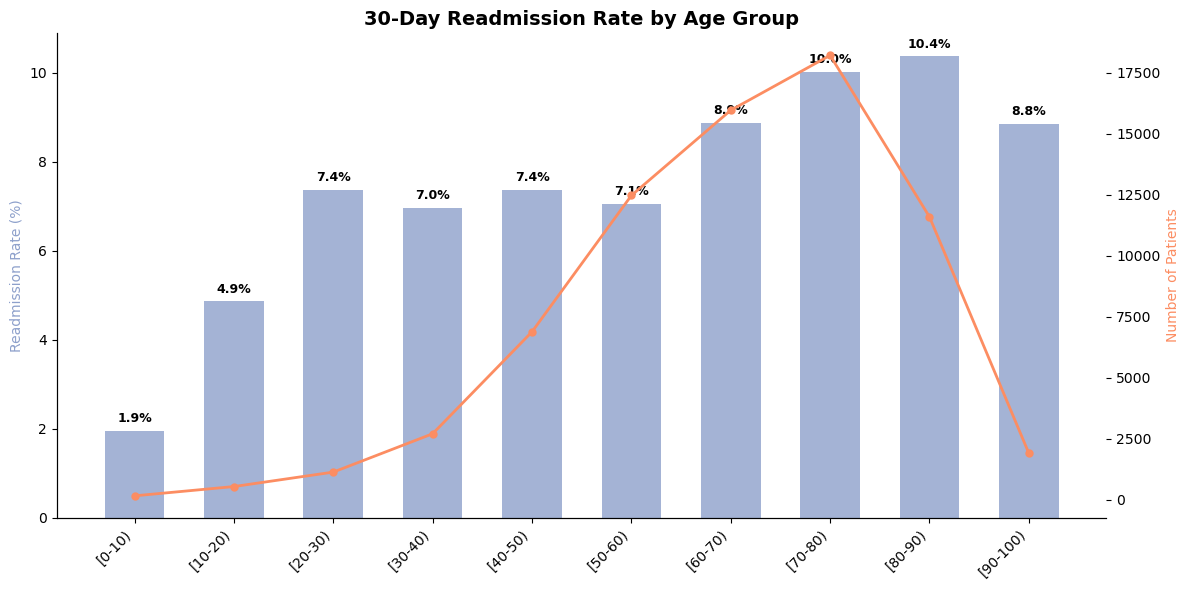

✓ Chart saved


In [3]:
# ── Readmission rate by age group ─────────────────────────

age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)",
             "[40-50)", "[50-60)", "[60-70)", "[70-80)",
             "[80-90)", "[90-100)"]

age_readmit = (
    df.groupby("age")["readmitted_30"]
    .agg(["mean", "count"])
    .reset_index()
)
age_readmit["mean"] = age_readmit["mean"] * 100
age_readmit = age_readmit.set_index("age").reindex(age_order)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(range(len(age_order)),
               age_readmit["mean"].values,
               color="#8da0cb", width=0.6, alpha=0.8)
ax1.set_xticks(range(len(age_order)))
ax1.set_xticklabels(age_order, rotation=45, ha="right")
ax1.set_ylabel("Readmission Rate (%)", color="#8da0cb")
ax1.set_title("30-Day Readmission Rate by Age Group",
              fontsize=14, fontweight="bold")

for bar, val in zip(bars, age_readmit["mean"].values):
    if not np.isnan(val):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{val:.1f}%", ha="center",
                 fontsize=9, fontweight="bold")

# Add patient count line
ax2 = ax1.twinx()
ax2.plot(range(len(age_order)),
         age_readmit["count"].values,
         color="#fc8d62", linewidth=2,
         marker="o", markersize=5)
ax2.set_ylabel("Number of Patients", color="#fc8d62")

plt.tight_layout()
plt.savefig("../dashboard/02_readmission_by_age.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

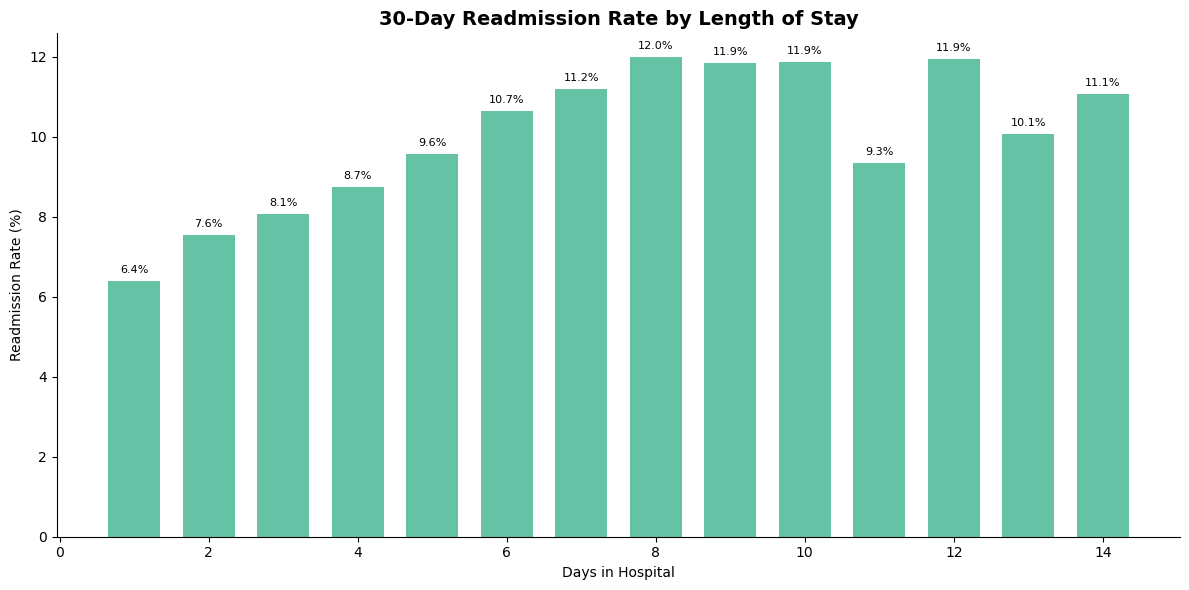

✓ Chart saved


In [4]:
# ── Readmission rate by length of stay ────────────────────

stay_readmit = (
    df.groupby("time_in_hospital")["readmitted_30"]
    .agg(["mean", "count"])
    .reset_index()
)
stay_readmit["mean"] = stay_readmit["mean"] * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(stay_readmit["time_in_hospital"],
       stay_readmit["mean"],
       color="#66c2a5", width=0.7)
ax.set_title("30-Day Readmission Rate by Length of Stay",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Days in Hospital")
ax.set_ylabel("Readmission Rate (%)")

for _, row in stay_readmit.iterrows():
    ax.text(row["time_in_hospital"],
            row["mean"] + 0.2,
            f"{row['mean']:.1f}%",
            ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../dashboard/03_readmission_by_stay.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

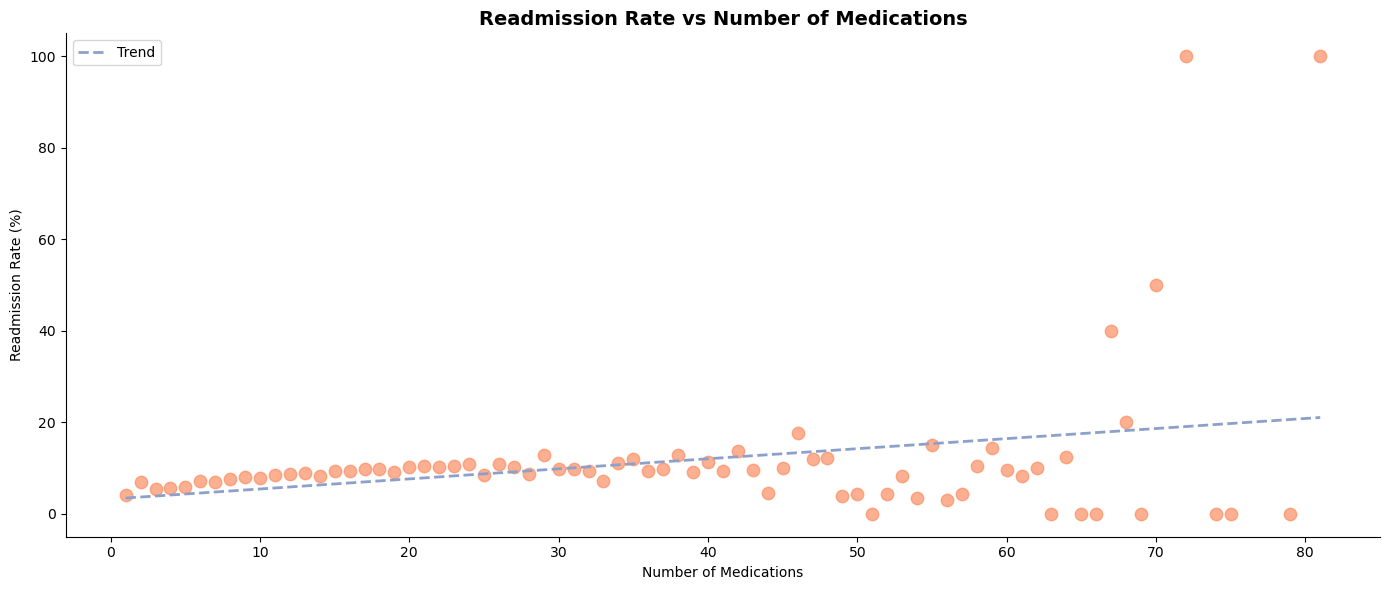

✓ Chart saved


In [5]:
# ── Readmission by medication count ───────────────────────

med_readmit = (
    df.groupby("num_medications")["readmitted_30"]
    .mean() * 100
).reset_index()
med_readmit.columns = ["num_medications", "readmission_rate"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(med_readmit["num_medications"],
           med_readmit["readmission_rate"],
           color="#fc8d62", s=80, alpha=0.7)

# Trend line
z = np.polyfit(med_readmit["num_medications"],
               med_readmit["readmission_rate"], 1)
p = np.poly1d(z)
ax.plot(med_readmit["num_medications"],
        p(med_readmit["num_medications"]),
        color="#8da0cb", linewidth=2,
        linestyle="--", label="Trend")

ax.set_title("Readmission Rate vs Number of Medications",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Medications")
ax.set_ylabel("Readmission Rate (%)")
ax.legend()

plt.tight_layout()
plt.savefig("../dashboard/04_readmission_by_medications.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

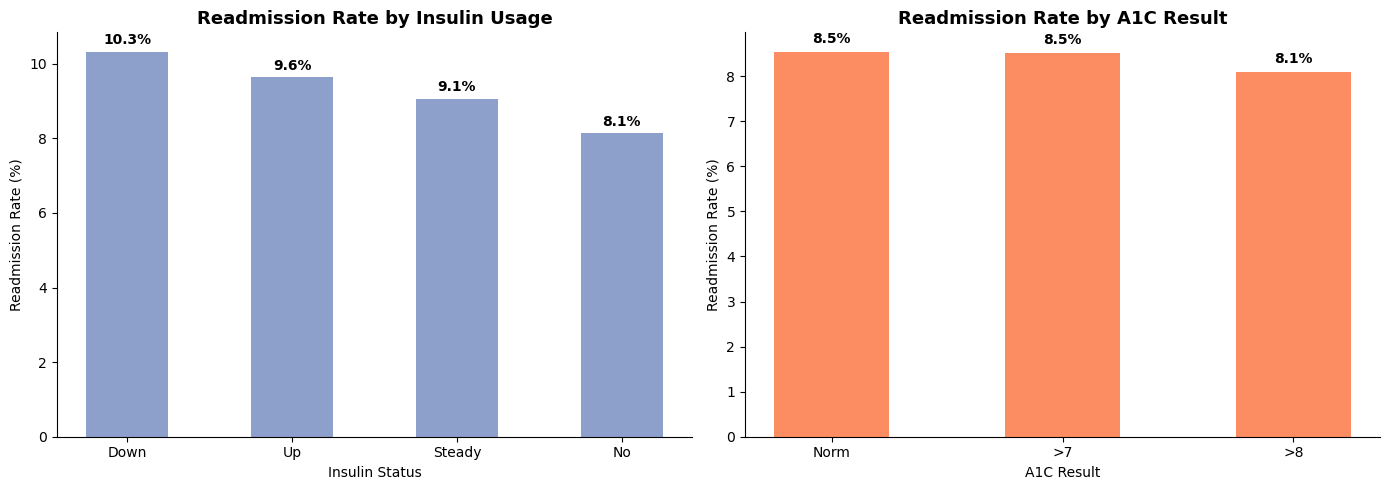

✓ Chart saved


In [6]:
# ── Readmission by insulin and A1C ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Insulin
insulin_readmit = (
    df.groupby("insulin")["readmitted_30"]
    .mean() * 100
).sort_values(ascending=False)

axes[0].bar(insulin_readmit.index,
            insulin_readmit.values,
            color="#8da0cb", width=0.5)
axes[0].set_title("Readmission Rate by Insulin Usage",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].set_xlabel("Insulin Status")
for i, val in enumerate(insulin_readmit.values):
    axes[0].text(i, val + 0.2, f"{val:.1f}%",
                 ha="center", fontweight="bold")

# A1C result
a1c_readmit = (
    df.groupby("A1Cresult")["readmitted_30"]
    .mean() * 100
).sort_values(ascending=False)

axes[1].bar(a1c_readmit.index,
            a1c_readmit.values,
            color="#fc8d62", width=0.5)
axes[1].set_title("Readmission Rate by A1C Result",
                  fontsize=13, fontweight="bold")
axes[1].set_ylabel("Readmission Rate (%)")
axes[1].set_xlabel("A1C Result")
for i, val in enumerate(a1c_readmit.values):
    axes[1].text(i, val + 0.2, f"{val:.1f}%",
                 ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../dashboard/05_insulin_a1c.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

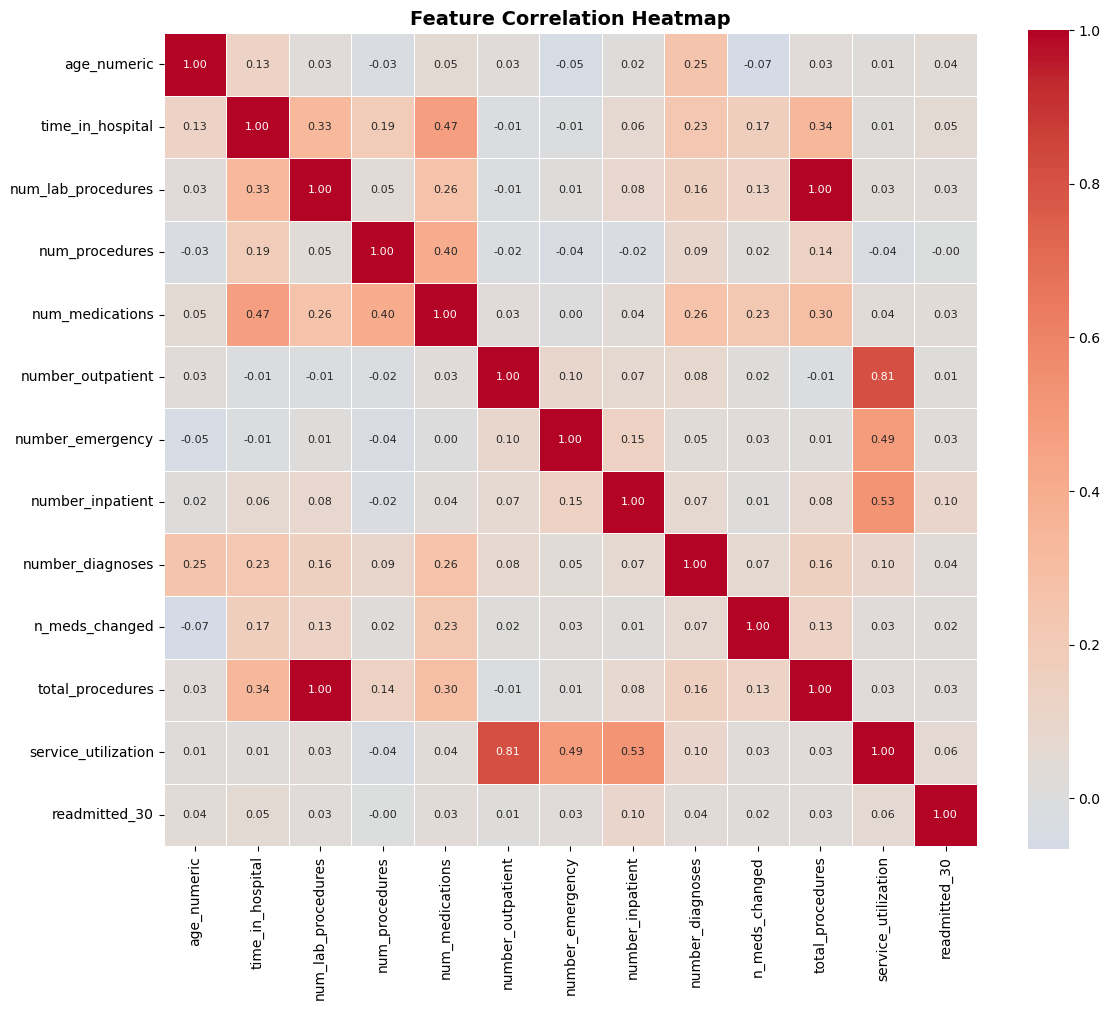

✓ Chart saved


In [7]:
# ── Correlation heatmap ────────────────────────────────────

numeric_cols = [
    "age_numeric", "time_in_hospital", "num_lab_procedures",
    "num_procedures", "num_medications", "number_outpatient",
    "number_emergency", "number_inpatient", "number_diagnoses",
    "n_meds_changed", "total_procedures", "service_utilization",
    "readmitted_30"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Feature Correlation Heatmap",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../dashboard/06_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

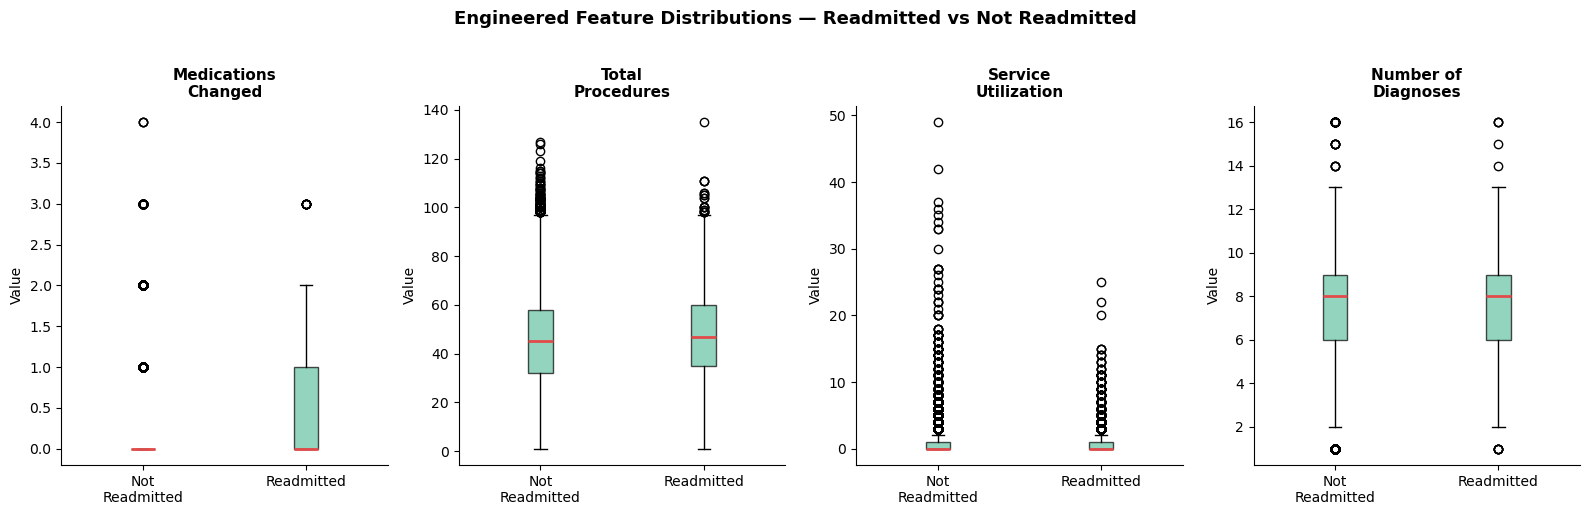

✓ Chart saved


In [8]:
# ── Engineered features — readmitted vs not ───────────────

features = [
    "n_meds_changed",
    "total_procedures",
    "service_utilization",
    "number_diagnoses"
]
feature_labels = [
    "Medications\nChanged",
    "Total\nProcedures",
    "Service\nUtilization",
    "Number of\nDiagnoses"
]

readmitted     = df[df["readmitted_30"] == 1]
not_readmitted = df[df["readmitted_30"] == 0]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    axes[i].boxplot(
        [not_readmitted[feature].dropna(),
         readmitted[feature].dropna()],
        labels=["Not\nReadmitted", "Readmitted"],
        patch_artist=True,
        boxprops=dict(facecolor="#66c2a5", alpha=0.7),
        medianprops=dict(color="#E24B4A", linewidth=2)
    )
    axes[i].set_title(label, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Value")

plt.suptitle(
    "Engineered Feature Distributions — Readmitted vs Not Readmitted",
    fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../dashboard/07_engineered_features.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

In [9]:
readmit_rate = df["readmitted_30"].mean() * 100
high_risk_age = (
    df.groupby("age")["readmitted_30"]
    .mean().idxmax()
)
top_insulin = (
    df.groupby("insulin")["readmitted_30"]
    .mean().idxmax()
)

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EDA KEY FINDINGS — PATIENT READMISSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  OVERALL
  → 30-day readmission rate: {readmit_rate:.1f}%
  → Dataset is imbalanced — will need SMOTE

  PATIENT DEMOGRAPHICS
  → Highest risk age group: {high_risk_age}
  → Older patients show consistently higher
    readmission rates

  CLINICAL FACTORS
  → More medications = higher readmission risk
  → Longer hospital stays = higher readmission risk
  → Insulin status '{top_insulin}' has highest
    readmission rate

  ENGINEERED FEATURES
  → Service utilization strongest predictor
  → Readmitted patients have more diagnoses
    and more medications changed

  CLASS IMBALANCE
  → Only ~11% of patients are readmitted
  → SMOTE will be applied in Phase 4 to
    balance classes before model training

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EDA KEY FINDINGS — PATIENT READMISSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  OVERALL
  → 30-day readmission rate: 8.8%
  → Dataset is imbalanced — will need SMOTE

  PATIENT DEMOGRAPHICS
  → Highest risk age group: [80-90)
  → Older patients show consistently higher
    readmission rates

  CLINICAL FACTORS
  → More medications = higher readmission risk
  → Longer hospital stays = higher readmission risk
  → Insulin status 'Down' has highest
    readmission rate

  ENGINEERED FEATURES
  → Service utilization strongest predictor
  → Readmitted patients have more diagnoses
    and more medications changed

  CLASS IMBALANCE
  → Only ~11% of patients are readmitted
  → SMOTE will be applied in Phase 4 to
    balance classes before model training

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

